# 01 Data Acquisition and Exploratory Data Analysis (EDA)

This notebook covers **Task 1: Data Acquisition and EDA** for the raw-only UCI Heart Disease MLOps assignment.

It demonstrates:

- downloading the official raw UCI Heart Disease files,
- extracting the 14 documented ML variables from the original 76-attribute records,
- handling missing values,
- converting the target into binary classification,
- inspecting data types and missing values,
- checking class balance,
- generating professional EDA visualizations, and
- saving EDA evidence files for the final report.


## 1. Set project path

This cell allows the notebook to import reusable Python modules from the `src/` folder whether the notebook is opened from the project root or from the `notebooks/` folder.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))
print("Project root:", project_root)


Project root: c:\Users\ASUS\MLOPS\mlops-heart-disease-v3


## 2. Download and prepare raw-only UCI data

The project uses only the raw UCI files for model development:

- `cleveland.data`
- `hungarian.data`
- `switzerland.data`
- `long-beach-va.data`

The script downloads the files into `data/raw/uci_full_archive/` and creates a cleaned dataset in `data/processed/`.


In [2]:
from src.data_acquisition import main as acquire_data

acquire_data()


2026-07-07 22:07:50,551 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/heart-disease.names
2026-07-07 22:07:52,407 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/Index
2026-07-07 22:07:53,194 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/WARNING
2026-07-07 22:07:54,379 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/ask-detrano
2026-07-07 22:07:55,150 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/bak
2026-07-07 22:07:55,926 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/cleveland.data
2026-07-07 22:07:57,249 | INFO | Downloading UCI file: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/hungarian.data
2026-07-07 22:07:58,543 | INFO 

## 3. Load the cleaned modeling dataset

The raw files are parsed into the selected 14-variable ML structure. The cleaned modeling file contains the 13 input features, one `source_database` evidence column, and the binary target.


In [3]:
import pandas as pd
from src.config import CLEAN_DATA_PATH, FEATURE_COLUMNS, SOURCE_COLUMN, TARGET_COLUMN

df = pd.read_csv(CLEAN_DATA_PATH)
print("Dataset path:", CLEAN_DATA_PATH)
print("Shape:", df.shape)
df.head()


Dataset path: C:\Users\ASUS\MLOPS\mlops-heart-disease-v3\data\processed\heart_disease_raw_only_all_sites_cleaned.csv
Shape: (907, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_database,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,cleveland,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,cleveland,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,cleveland,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,cleveland,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,cleveland,0


## 4. Data type inspection

This confirms whether the variables are numeric/categorical and ready for preprocessing.


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              905 non-null    float64
 1   sex              903 non-null    float64
 2   cp               906 non-null    float64
 3   trestbps         844 non-null    float64
 4   chol             874 non-null    float64
 5   fbs              813 non-null    float64
 6   restecg          901 non-null    float64
 7   thalach          849 non-null    float64
 8   exang            849 non-null    float64
 9   oldpeak          844 non-null    float64
 10  slope            593 non-null    float64
 11  ca               295 non-null    float64
 12  thal             428 non-null    float64
 13  source_database  907 non-null    object 
 14  target           907 non-null    int64  
dtypes: float64(13), int64(1), object(1)
memory usage: 106.4+ KB


## 5. Missing value analysis

Raw UCI records contain missing markers such as `-9` and sometimes `?`. The data acquisition script converts those markers to missing values. Remaining missing values are handled later through the sklearn preprocessing pipeline.


In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values


ca                 612
thal               479
slope              314
fbs                 94
oldpeak             63
trestbps            63
thalach             58
exang               58
chol                33
restecg              6
sex                  4
age                  2
cp                   1
source_database      0
target               0
dtype: int64

## 6. Class balance analysis

The original UCI diagnosis field is converted into binary target classes:

- `0` = no heart disease
- `1` = heart disease risk present


In [6]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()
class_ratio = df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
pd.DataFrame({"count": class_counts, "ratio": class_ratio})


,count,ratio
target,,
0,405,0.446527
1,502,0.553473


## 7. Source database distribution

This confirms that the cleaned dataset uses records extracted from the four original raw UCI source files.


In [7]:
df[SOURCE_COLUMN].value_counts()


source_database
hungarian        294
cleveland        290
long_beach_va    200
switzerland      123
Name: count, dtype: int64

## 8. Generate and save all EDA outputs

This runs `src/eda.py`, which creates the required EDA tables and professional visualization files. Outputs are saved to:

- `artifacts/eda/`
- `artifacts/figures/eda/`
- `screenshots/eda/`


In [8]:
from src.eda import main as run_eda

run_eda()


2026-07-07 22:08:11,225 | INFO | Loaded EDA dataset from C:\Users\ASUS\MLOPS\mlops-heart-disease-v3\data\processed\heart_disease_raw_only_all_sites_cleaned.csv with shape (907, 15)
2026-07-07 22:08:11,290 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 22:08:11,293 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 22:08:11,412 | INFO | Saved EDA figure: C:\Users\ASUS\MLOPS\mlops-heart-disease-v3\artifacts\figures\eda\01_class_balance.png
2026-07-07 22:08:11,528 | INFO | Saved EDA figure: C:\Users\ASUS\MLOPS\mlops-heart-disease-v3\artifacts\figures\eda\02_source_distribution.png
2026-07-07 22:08:12,528 | INFO | Saved EDA figure: C:\Users\ASUS\MLOPS\mlops-heart-disease-v3

## 9. Show generated EDA files

Use these PNG files as screenshot evidence in the final report.


In [9]:
from pathlib import Path

eda_fig_dir = project_root / "artifacts" / "figures" / "eda"
for path in sorted(eda_fig_dir.glob("*.png")):
    print(path.relative_to(project_root))


artifacts\figures\eda\01_class_balance.png
artifacts\figures\eda\02_source_distribution.png
artifacts\figures\eda\03_feature_histograms.png
artifacts\figures\eda\04_correlation_heatmap.png
artifacts\figures\eda\05_thalach_by_target.png
artifacts\figures\eda\06_age_cholesterol_by_target.png


## 10. Display saved EDA visuals

The figures below are generated from the local raw-only UCI data run. If the notebook is re-run, these visuals are regenerated and overwritten.


01_class_balance.png


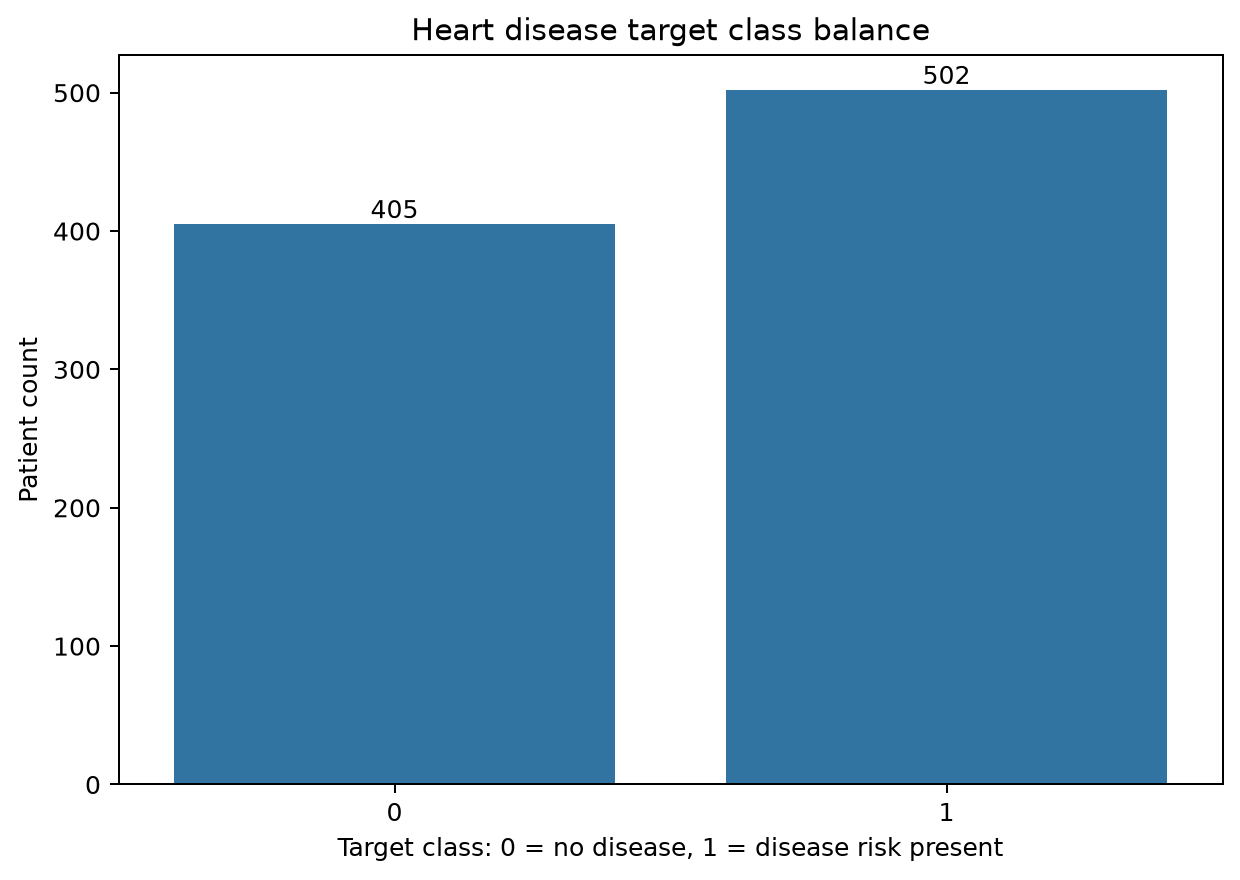

02_source_distribution.png


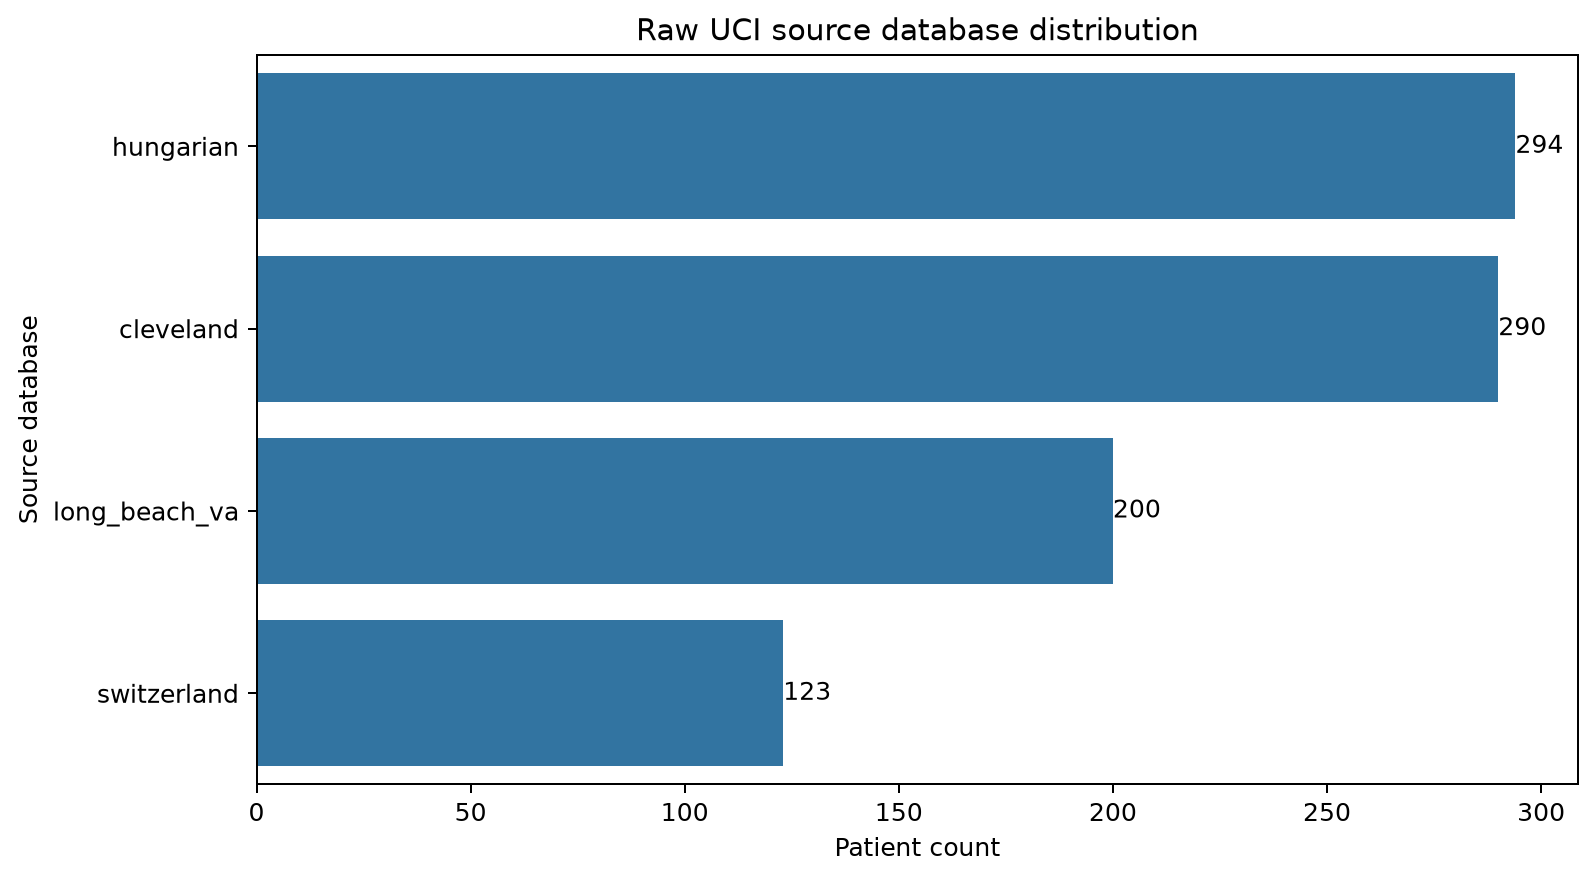

03_feature_histograms.png


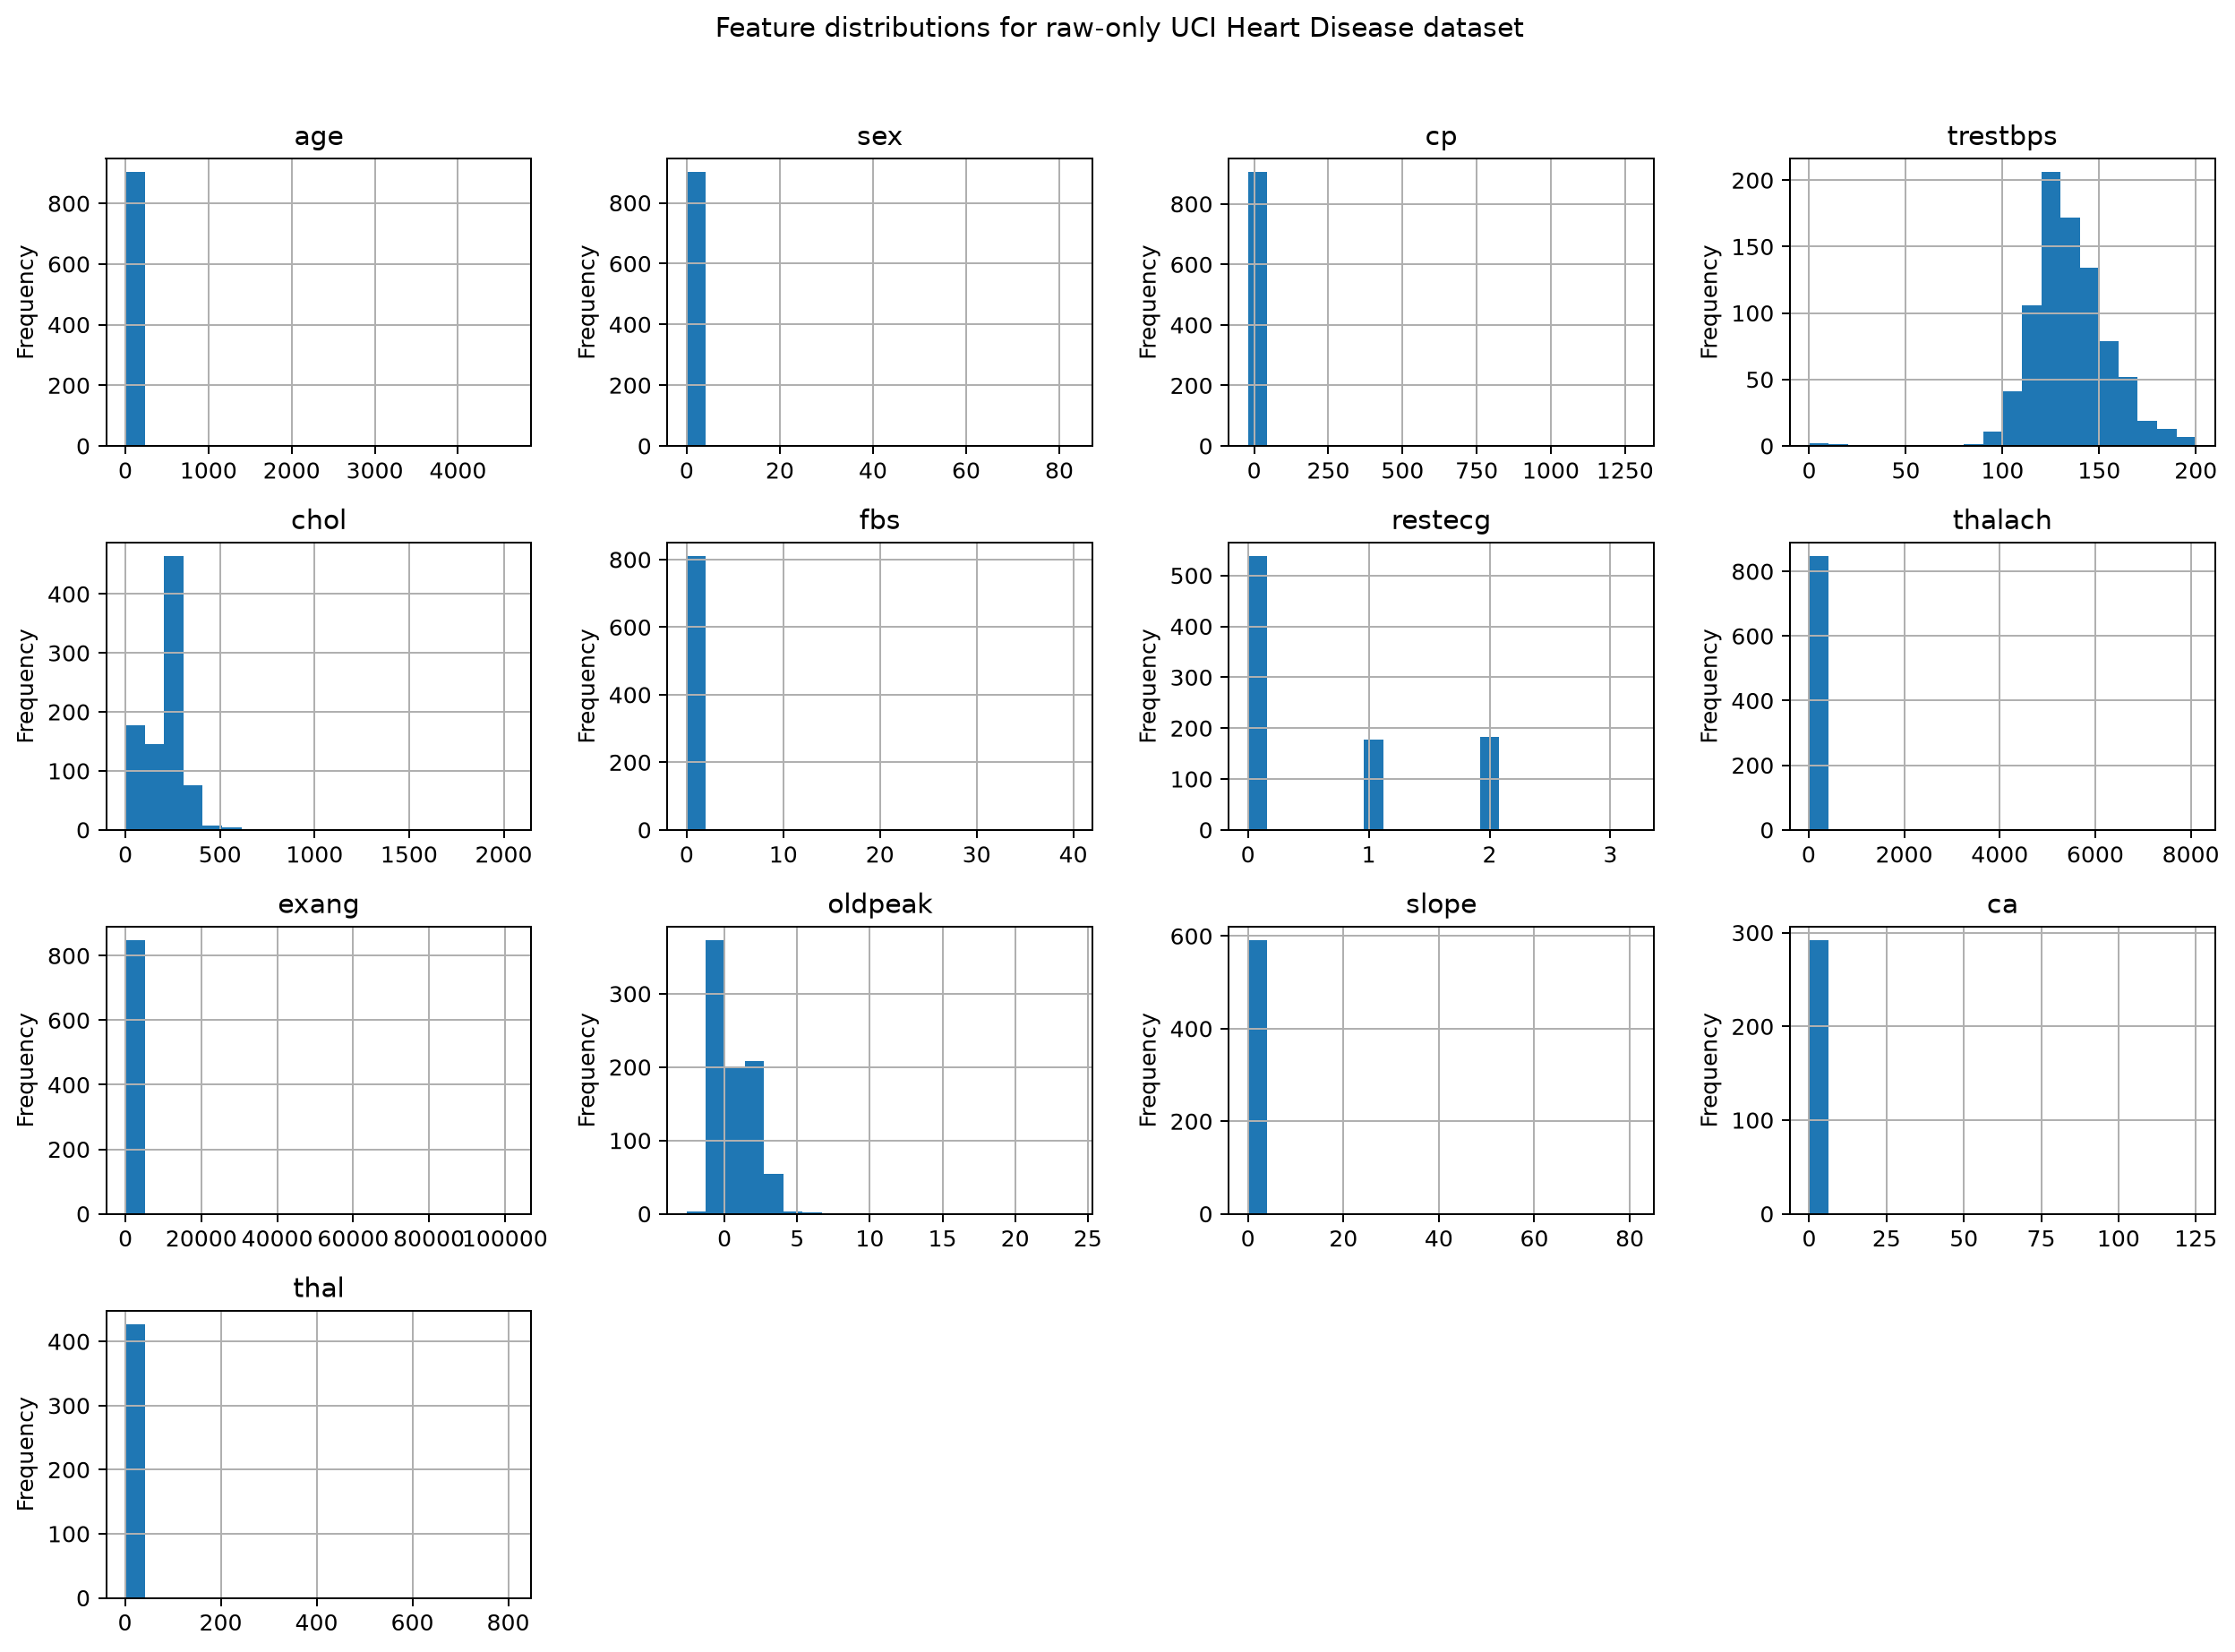

04_correlation_heatmap.png


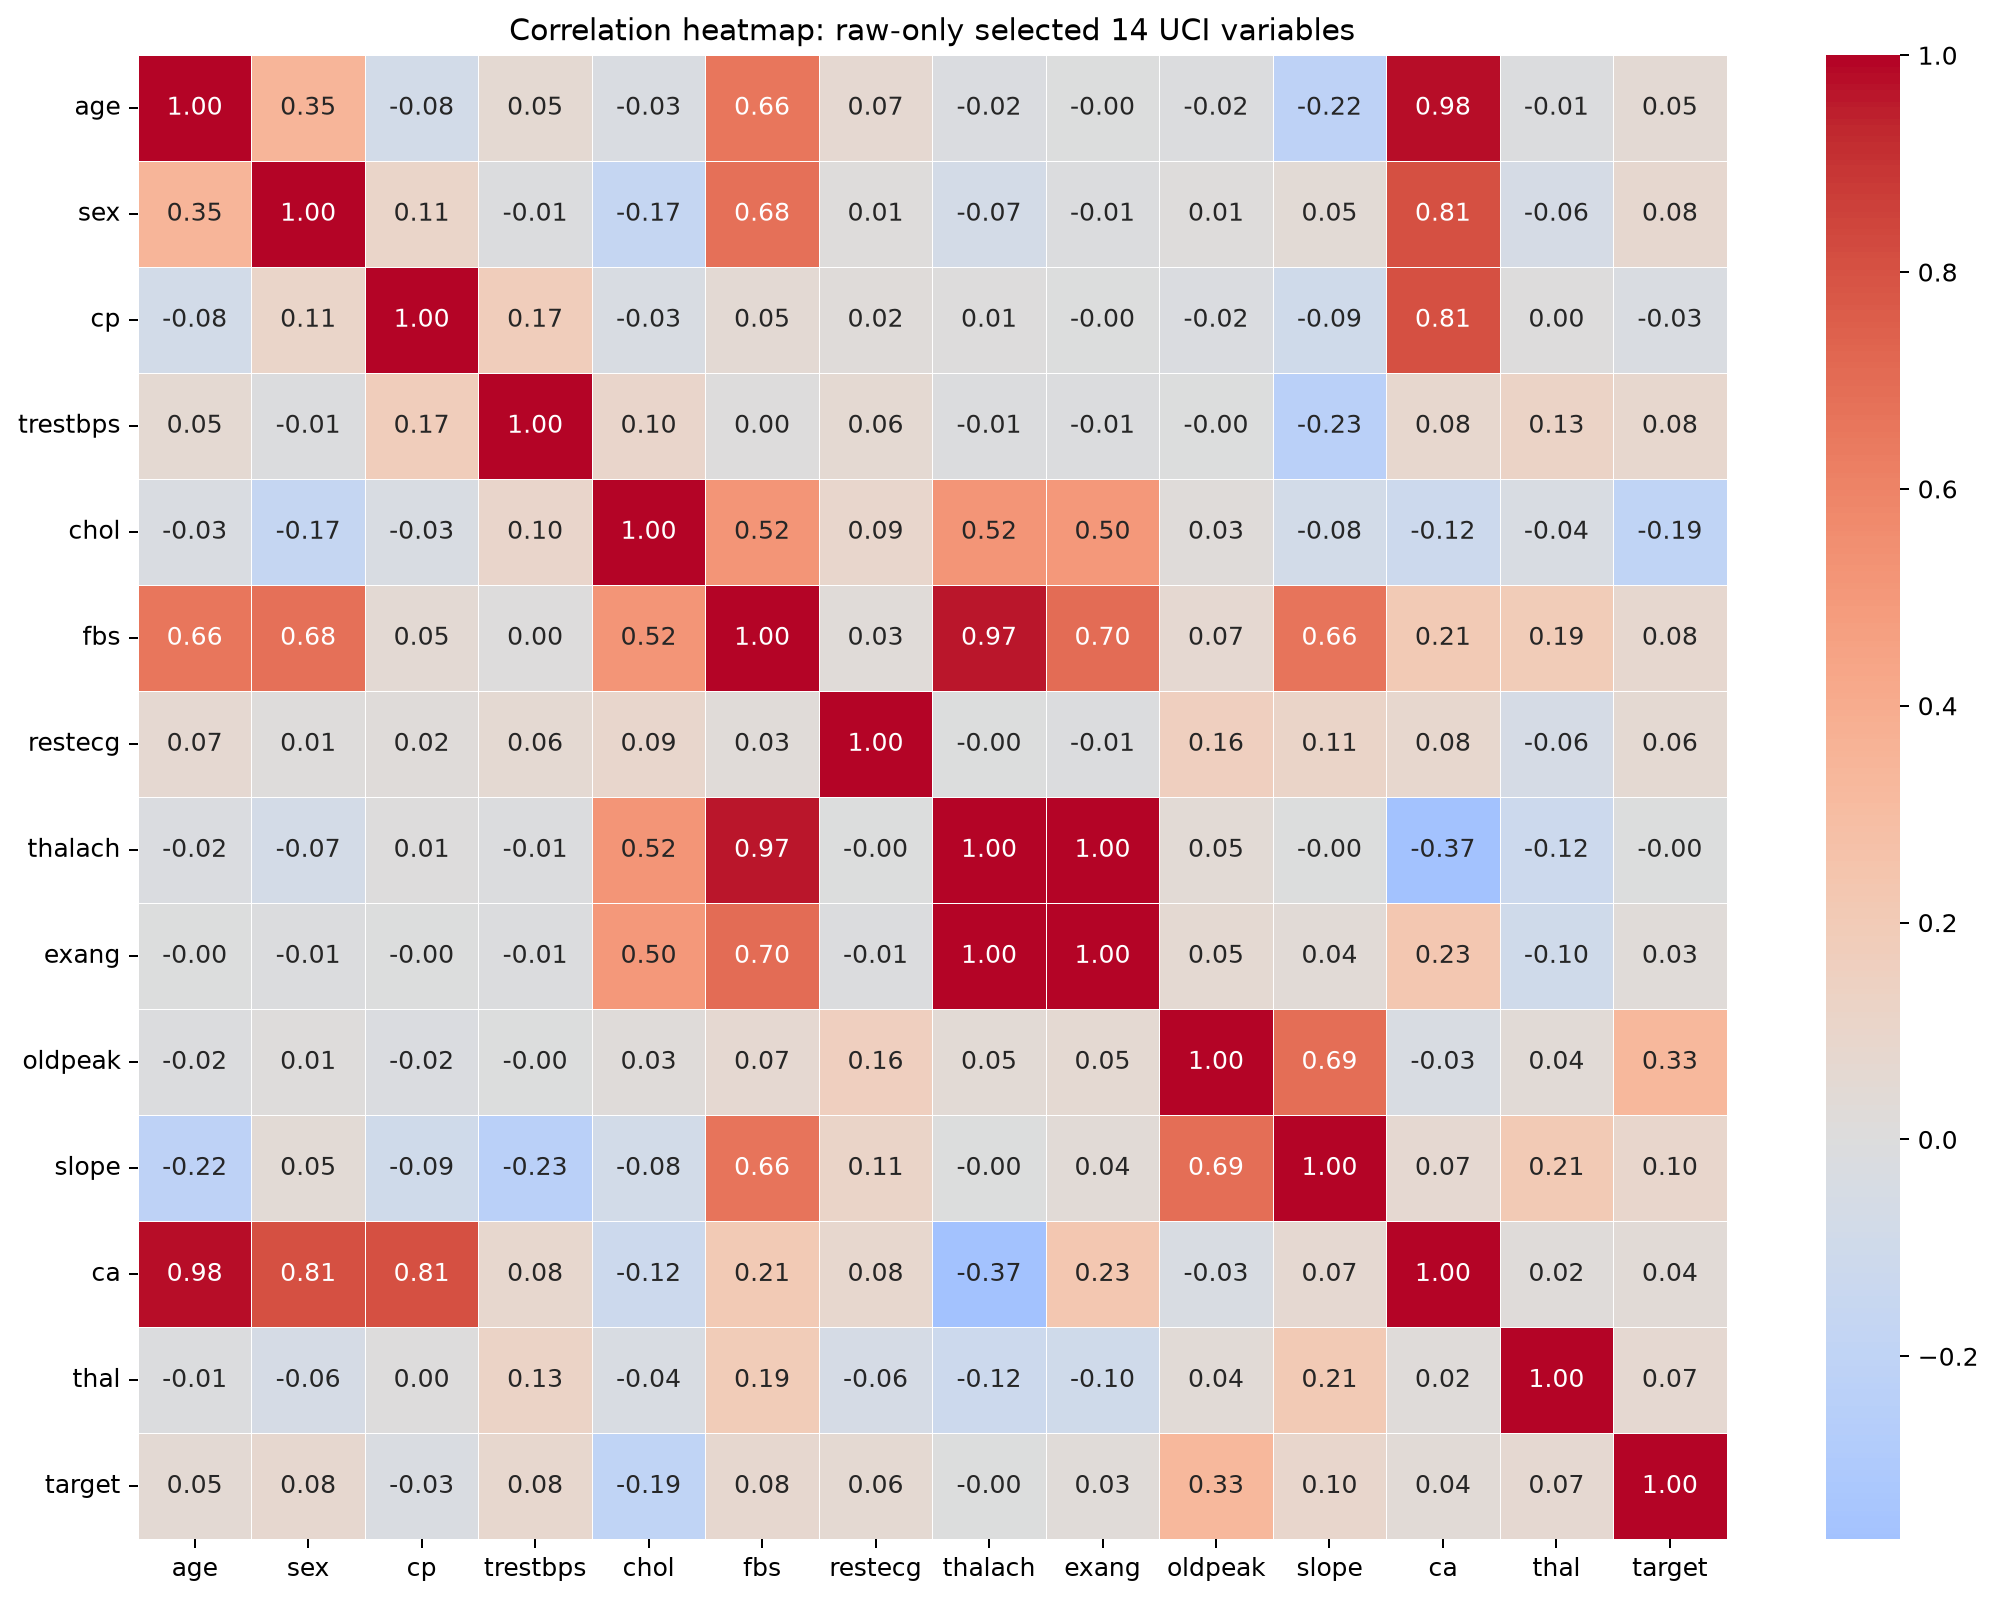

05_thalach_by_target.png


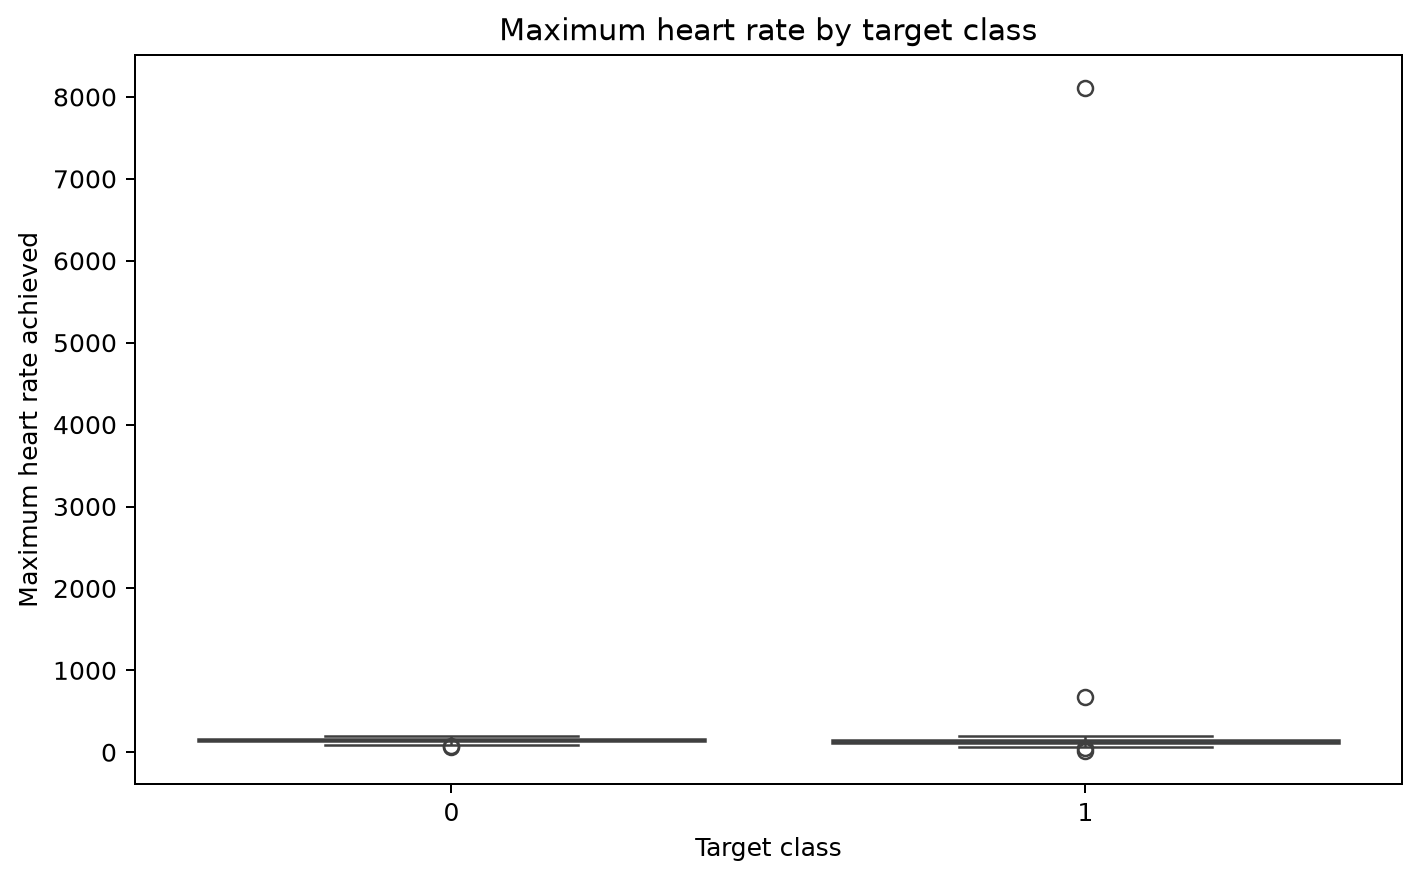

06_age_cholesterol_by_target.png


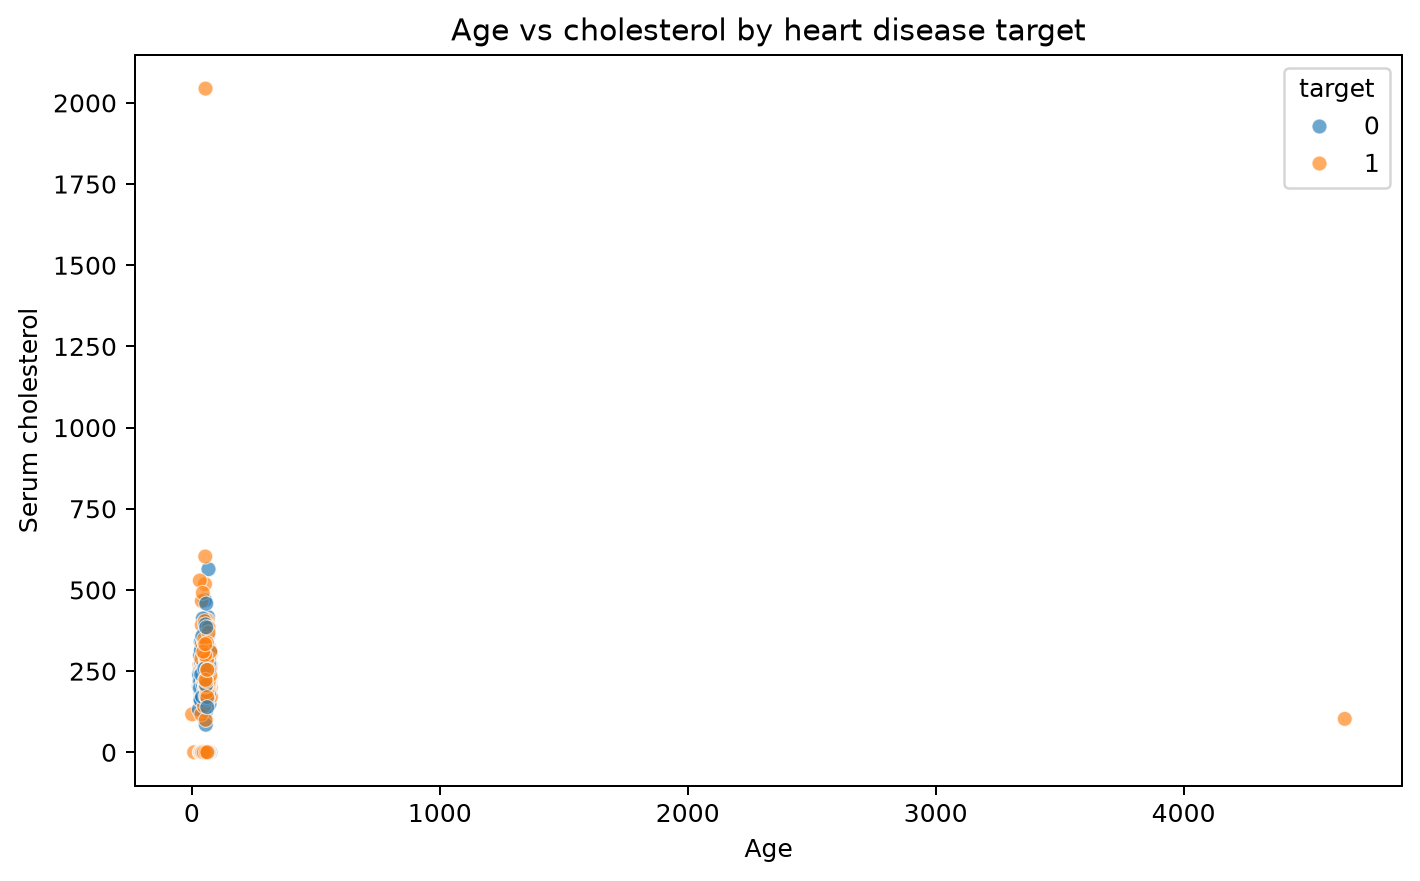

In [10]:
from IPython.display import Image, display

for image_name in [
    "01_class_balance.png",
    "02_source_distribution.png",
    "03_feature_histograms.png",
    "04_correlation_heatmap.png",
    "05_thalach_by_target.png",
    "06_age_cholesterol_by_target.png",
]:
    image_path = eda_fig_dir / image_name
    if image_path.exists():
        print(image_name)
        display(Image(filename=str(image_path)))


## 11. EDA interpretation notes

Use these points in the final report after reviewing your generated plots:

1. Confirm whether the target is reasonably balanced or imbalanced.
2. Check whether the four source databases contribute records as expected.
3. Identify features with visible distribution differences between target classes.
4. Review the correlation heatmap for strong positive or negative relationships.
5. Highlight any missing-value concerns and explain that the model pipeline uses imputation.
